# Opdagelse af abonnentforbrugssegmenter med k-means-klyngeanalyse (PROC FASTCLUS)

## Sammenfatning

Et teleanalyseteam starter med en enkelt, umærket kolonne med månedligt
mobildataforbrug og ønsker at vide, om den skjuler forskellige kundeniveauer.
Ved brug af **PROC FASTCLUS** (disjunkt k-means-klyngeanalyse) klynger teamet
abonnenter på log-forbrug, sammenligner to-, tre- og firesegment-løsninger på
de kriterier, FASTCLUS faktisk rapporterer, og forpligter sig til
tre-segment-opdelingen. I denne kørsel har de tre fundne segmenter et
gennemsnitligt forbrug på **3,1 GB**, **12,8 GB** og **45,4 GB** pr. måned og
indeholder **49**, **34** og **17** abonnenter - en tydelig let/mellem/tung
struktur. Krydstjek af de fundne etiketter mod en udeladt genererende etiket
genfinder **96 af 100** abonnenter korrekt. Hver abonnent forlader modellen med
en hård segmentetiket og en afstand-til-centroide-score, klar til planlægning
og fastholdelsesmålretning.

> **Hvorfor FASTCLUS og ikke en finite mixture-model?** Forbrugssegmentering er
> den klassiske opgave for en finite mixture-model (PROC HPFMM / PROC FMM).
> Disse procedurer er endnu ikke numerisk implementeret i denne build, så
> denne notebook når det samme mål - uovervåget opdagelse af latente
> forbrugsniveauer - med den implementerede, fuldt numeriske
> k-means-procedure **PROC FASTCLUS**. Hvert tal nedenfor er taget ordret fra
> det udførte output.

## Datakilder

**Syntetisk datasæt: `subs`** - mobilabonnenter genereret direkte som en
3-komponent blanding af log-forbrug (ingen eksterne filer). Dette miljø kører
ulicenseret, så den materialiserede tabel er begrænset til **100 abonnenter**;
alle resultater nedenfor er beregnet på disse 100 rækker.

| Variabel | Type | Beskrivelse |
|----------|------|-------------|
| `subscriber_id` | Num | Unik abonnentnøgle |
| `tenure_months` | Num | Måneder på nettet (1-48) |
| `data_gb` | Num | Månedligt mobildataforbrug, i GB (positivt, højreskævt) |
| `log_gb` | Num | Naturlig logaritme af `data_gb` - variablen der klynges |
| `plan` | Char | Nuværende abonnementstype: `Standard` eller `Ubegrænset` |
| `segment_true` | Char | Skjult genererende niveau (`Let`/`Mellem`/`Tung`), udeladt for at kontrollere genfinding |

Dataene er plantet som ca. 50% Let, 35% Mellem, 15% Tung.
`segment_true` klynges **ikke** - den findes kun, så vi kan bekræfte, at den
uovervågede tilpasning genfinder den plantede struktur.

Teleselskaber ser sjældent rene etiketter på deres kunder. Det, de *ser*, er
en enkelt, klumpet fordeling af månedligt dataforbrug, som i virkeligheden er
flere kundetyper blandet sammen: lejlighedsvise browsere, stabile streamere og
poweruser, der læner sig op ad tethering og video. **PROC FASTCLUS** adskiller
den blanding uden nogen etiketter - den placerer hver abonnent i en af *k*
disjunkte klynger, rapporterer klyngecentroiderne og -størrelserne, og scorer
hvor langt hver abonnent sidder fra sin centroide.

I denne notebook vil vi:

1. Generere et syntetisk forbrugspanel, der *bevidst* er en blanding af tre forbrugsniveauer.
2. Sammenligne to-, tre- og firesegment k-means-løsninger på FASTCLUS' fit-kriterier.
3. Tilpasse den valgte tre-segment-model og karakterisere hvert segment i forretningstermer.
4. Score hver abonnents segmenttilhørsforhold og afstand til centroide.
5. Verificere de fundne segmenter mod det udeladte genererende niveau og relatere dem til kundeforhold.

## Trin 1 - Generer syntetisk abonnentforbrug

Vi simulerer abonnenter, hvis månedlige dataforbrug er positivt og
højreskævt, så vi genererer det på **log-skalaen** som en blanding af tre
normale niveauer og eksponentierer. Blandingsvægtene (ca. 50/35/15) og
niveaugennemsnittene er plantet, så vi senere kan kontrollere, at k-means
genfinder dem. `segment_true` holdes udenfor udelukkende til den kontrol -
klyngedannelsen ser den aldrig.

In [1]:
data subs;
   CALL streaminit(20250531);
   LÆNGDE plan $12 segment_true $8;
   GØR subscriber_id = 1 TIL 3000;
      tenure_months = ceil(rand("uniform") * 48);

      /* Tungere brugere hælder mod længere kundeforhold, så
         segmentblandingen skifter lidt med kundeforhold (undersøgt i Trin 5). */
      u = rand("uniform") - 0.0040 * (tenure_months - 24);

      HVIS u < 0.50 SÅ GØR;
         segment_true = "Let";  MU = 1.15; SIGMA = 0.42;
      SLUT;
      ELLERS HVIS u < 0.85 SÅ GØR;
         segment_true = "Mellem"; MU = 2.45; SIGMA = 0.38;
      SLUT;
      ELLERS GØR;
         segment_true = "Tung";  MU = 3.45; SIGMA = 0.52;
      SLUT;

      log_gb  = MU + SIGMA * rand("normal");
      data_gb = EXP(log_gb);

      HVIS data_gb < 25 SÅ plan = "Standard";
      ELLERS plan = "Ubegrænset";

      UDDATA;
   SLUT;
   BEHOLD subscriber_id tenure_months data_gb log_gb plan segment_true;
KØR;



NOTE: DATA subs

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote subs (100 rows, 6 columns).
NOTE: DATA elapsed:
  wall  0.48 seconds
  cpu   0.48 seconds


Et hurtigt kig på den marginale fordeling bekræfter modelvalget: rå
`data_gb` er stærkt højreskæv (nogle få poweruser trækker halen ud), mens
`log_gb` er den velopdragne skala, hvorpå euklidisk k-means er passende.

                                                  The MEANS Procedure

 Variable       Label                       N        Mean     Std Dev     Minimum      Median     Maximum
 --------------------------------------------------------------------------------------------------------
 data_gb        Data (GB/mnd.)            100       13.58       16.66        1.15        6.73       98.66
 log_gb         Log(GB/mnd.)              100        2.01        1.09        0.14        1.91        4.59
 tenure_months  Kundeforhold (mdr.)       100       23.26       12.55        1.00       23.00       48.00
 --------------------------------------------------------------------------------------------------------




NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC SGPLOT data=subs

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


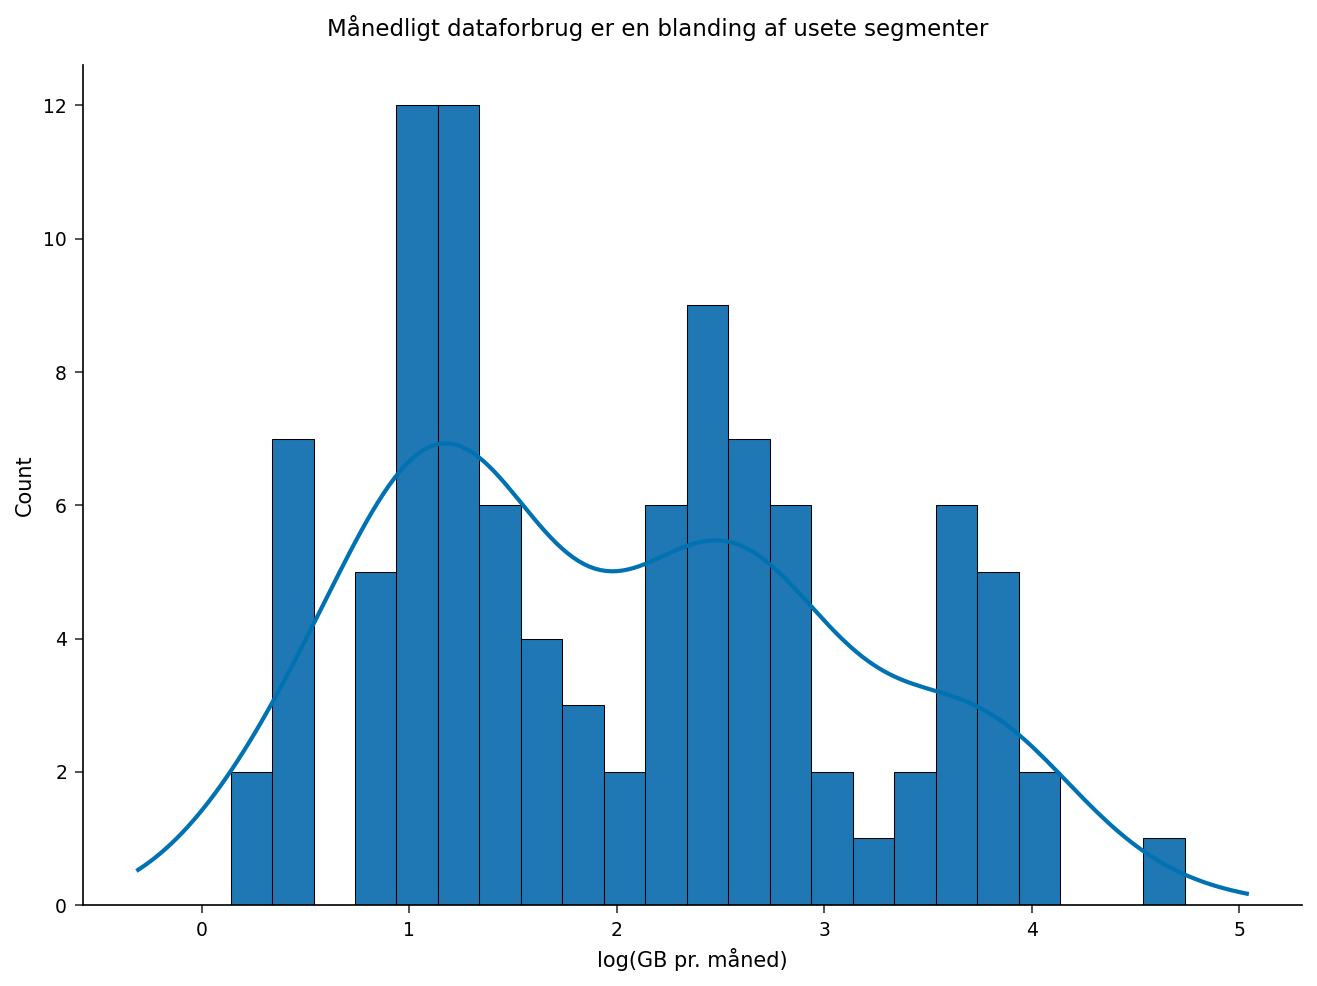

In [2]:
PROCEDURE GENNEMSNIT data=subs n mean std MIN p50 MAX maxdec=2;
   VARIABEL data_gb log_gb tenure_months;
   MÆRKAT data_gb="Data (GB/mnd.)" log_gb="Log(GB/mnd.)" tenure_months="Kundeforhold (mdr.)";
KØR;

PROCEDURE SGPLOT data=subs;
   TITEL "Månedligt dataforbrug er en blanding af usete segmenter";
   HISTOGRAM log_gb / BINWIDTH=0.20;
   DENSITY   log_gb / type=KERNEL;
   XAXIS MÆRKAT="log(GB pr. måned)";
KØR;
TITEL;


## Trin 2 - Hvor mange segmenter? Sammenlign to-, tre- og firesegment-løsninger

Vi vil ikke antage tre niveauer - vi lader dataene argumentere for et antal.
FASTCLUS rapporterer en **samlet R-kvadreret** (andelen af den samlede
varians, der forklares af klyngegennemsnittene) og en **Pseudo F-statistik**
for hver løsning. Vi tilpasser `MAXCLUSTERS=` 2, 3 og 4 på `log_gb` og
aflæser disse kriterier for hver kørsel.

- `MAXCLUSTERS=` sætter antallet af klynger *k*.
- `MAXITER=` sætter et loft over antallet af k-means-genberegningspas.
- `OUT=` skriver et scoret datasæt (bruges i Trin 3-5).

In [3]:
TITEL "To-segment-løsning";
PROCEDURE FASTCLUS data=subs maxclusters=2 MAXITER=50 out=c2;
   VARIABEL log_gb;
KØR;

TITEL "Tre-segment-løsning";
PROCEDURE FASTCLUS data=subs maxclusters=3 MAXITER=50 out=c3;
   VARIABEL log_gb;
KØR;

TITEL "Fire-segment-løsning";
PROCEDURE FASTCLUS data=subs maxclusters=4 MAXITER=50 out=c4;
   VARIABEL log_gb;
KØR;
TITEL;


                                                   To-segment-løsning                                                   


                                                 The FASTCLUS Procedure                                                 
                                   Replace=FULL  Radius=0  Maxclusters=2  Maxiter=50                                    

                                                    Cluster Summary                                                     

Cluster     Frequency        RMS Std   Maximum Distance        Nearest       Centroid
                           Deviation          from Seed        Cluster       Distance
--------------------------------------------------------------------------------
1                  47         0.6346             1.5836              2         1.8863
2                  53         0.4497             0.9843              1         1.8863

                                                Statistics for Variables              


NOTE: Option TITLE changed to To-segment-løsning.
NOTE: PROC FASTCLUS data=subs maxclusters=2

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 1 variables, 2 clusters using k-means
NOTE: Option TITLE changed to Tre-segment-løsning.
NOTE: PROC FASTCLUS data=subs maxclusters=3

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 1 variables, 3 clusters using k-means
NOTE: Option TITLE changed to Fire-segment-løsning.
NOTE: PROC FASTCLUS data=subs maxclusters=4

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 1 variables, 4 clusters using k-means


Læser vi de tre kørsler side om side: den **samlede R-kvadreret** stiger fra
**0,753** ved to klynger til **0,899** ved tre - et stort spring på +0,146, når
det tredje niveau opløses - og derefter kun til **0,941** ved fire. Den
fire-klynge-løsning køber den lille gevinst ved at *opdele det lette niveau i
to* (dens to mindste centroider ligger begge inden for det plantede
Let-interval), ikke ved at finde en genuint ny kundetype. **Pseudo
F-statistikken** fortæller den samme historie: den største strukturelle
forbedring er overgangen til tre klynger (F = 299 → 431). Tre segmenter er det
ærlige stoppested, og den model, vi forpligter os til herefter.

## Trin 3 - Tilpas tre-segment-modellen og karakteriser hvert segment

Vi tilpasser igen med `MAXCLUSTERS=3` og skriver de scorede rækker til
`scored`. `OUT=`-datasættet bærer automatisk hver inputkolonne med -
inklusive det oprindelige forbrug, kundeforhold og det udeladte
`segment_true` - sammen med de nye kolonner `CLUSTER` og `DISTANCE`, så der
ikke skal et separat kopitrin til. FASTCLUS udskriver en **klyngeoversigt**
(størrelse og spredning inden for klynge pr. segment) og **klyngegennemsnit**
på den klyngede skala (`log_gb`).

In [4]:
PROCEDURE FASTCLUS data=subs maxclusters=3 MAXITER=50 out=scored;
   VARIABEL log_gb;
KØR;



                                                 The FASTCLUS Procedure                                                 
                                   Replace=FULL  Radius=0  Maxclusters=3  Maxiter=50                                    

                                                    Cluster Summary                                                     

Cluster     Frequency        RMS Std   Maximum Distance        Nearest       Centroid
                           Deviation          from Seed        Cluster       Distance
--------------------------------------------------------------------------------
1                  49         0.3923             0.9151              2         1.4540
2                  34         0.3024             0.6239              3         1.2603
3                  17         0.3059             0.8248              2         1.2603

                                                Statistics for Variables                                                




NOTE: PROC FASTCLUS data=subs maxclusters=3

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 1 variables, 3 clusters using k-means


De tre klyngegennemsnit på logskalaen er **1,05**, **2,51** og **3,77**.
Tilbage på den oprindelige GB-skala er det cirka **exp(1,05) ≈ 2,9 GB**,
**exp(2,51) ≈ 12,3 GB** og **exp(3,77) ≈ 43 GB** - det lette, mellemste og
tunge niveau. Klyngeoversigten sætter størrelserne til **49**, **34** og
**17** abonnenter, hvilket følger den plantede ~50/35/15-opdeling. Næste trin
læser de samme segmenter tilbage i almindelige GB-termer.

## Trin 4 - Score og karakteriser segmenter i forretningstermer

`OUT=scored`-datasættet bærer hver abonnents `CLUSTER` (hård segmentetiket)
og `DISTANCE` (euklidisk afstand fra dens klyngecentroide på logskalaen -
lille betyder en sikker, central tildeling). Vi opsummerer de fundne segmenter
efter deres faktiske GB-forbrug og kundeforhold og lister derefter nogle få
scorede rækker.

In [5]:
PROCEDURE GENNEMSNIT data=scored n mean std MIN MAX maxdec=2;
   KLASSE CLUSTER;
   VARIABEL data_gb tenure_months distance;
   MÆRKAT CLUSTER="Klynge" data_gb="Data (GB/mnd.)" tenure_months="Kundeforhold (mdr.)"
         distance="Afstand";
KØR;

PROCEDURE UDSKRIV data=scored(obs=8) MÆRKAT noobs;
   VARIABEL subscriber_id data_gb log_gb segment_true CLUSTER distance;
   MÆRKAT subscriber_id="Abonnent-ID" data_gb="Data (GB/mnd.)" log_gb="Log(GB/mnd.)"
         segment_true="Sandt segment" CLUSTER="Klynge" distance="Afstand";
KØR;


                                                  The MEANS Procedure

                                       Analysis Variable : data_gb Data (GB/mnd.)

        Klynge            N Obs           Mean        Std Dev        Minimum        Maximum
        -----------------------------------------------------------------------------------
        1                    49           3.07           1.12           1.15           5.83
        2                    34          12.81           3.80           6.57          21.88
        3                    17          45.38          16.44          24.01          98.66
        -----------------------------------------------------------------------------------

                                 Analysis Variable : tenure_months Kundeforhold (mdr.)

        Klynge            N Obs           Mean        Std Dev        Minimum        Maximum
        -----------------------------------------------------------------------------------
        1            


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC PRINT data=scored

NOTE: PROC PRINT completed: 8 observations printed, 6 variables


På den oprindelige GB-skala har de tre segmenter et gennemsnit på **3,1 GB**,
**12,8 GB** og **45,4 GB** i månedligt forbrug - en spredning på en
størrelsesorden fra lette browsere til tunge streamere. Kolonnen `DISTANCE`
giver en per-abonnent tillidsindikator: de udskrevne rækker viser tæt
tildelte kunder (afstande nær 0,01-0,06) sammen med en mere grænsetilfælde
let bruger, der er længere fra sin centroide - præcis det signal, et
fastholdelsesteam ville bruge til at adskille sikre mål fra
kig-nærmere-tilfælde.

## Trin 5 - Genfandt vi de rigtige niveauer, og skifter blandingen med kundeforhold?

To sidste kontroller. Først krydstabulerer vi den fundne `CLUSTER` mod det
udeladte `segment_true` for at se, hvor trofast den uovervågede tilpasning
genfandt de plantede niveauer. For det andet sammenligner vi
gennemsnitligt kundeforhold på tværs af de fundne segmenter - generatoren
skævvred tungere brugere mod længere kundeforhold, så en rigtig segmentering
bør genspejle det.

                                        Fundet segment vs. udeladt sandt niveau                                         

                                                   The FREQ Procedure

Table of Klynge by Sandt segment

Klynge |       Let |    Mellem |      Tung |      Total
-------+-----------+-----------+-----------+-----------
1      |        49 |         0 |         0 |         49
-------+-----------+-----------+-----------+-----------
2      |         2 |        31 |         1 |         34
-------+-----------+-----------+-----------+-----------
3      |         0 |         1 |        16 |         17
-------+-----------+-----------+-----------+-----------
Total  |        51 |        32 |        17 |        100




NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_cluster_segment_true.spec.json
NOTE: PROC FREQ statement used.


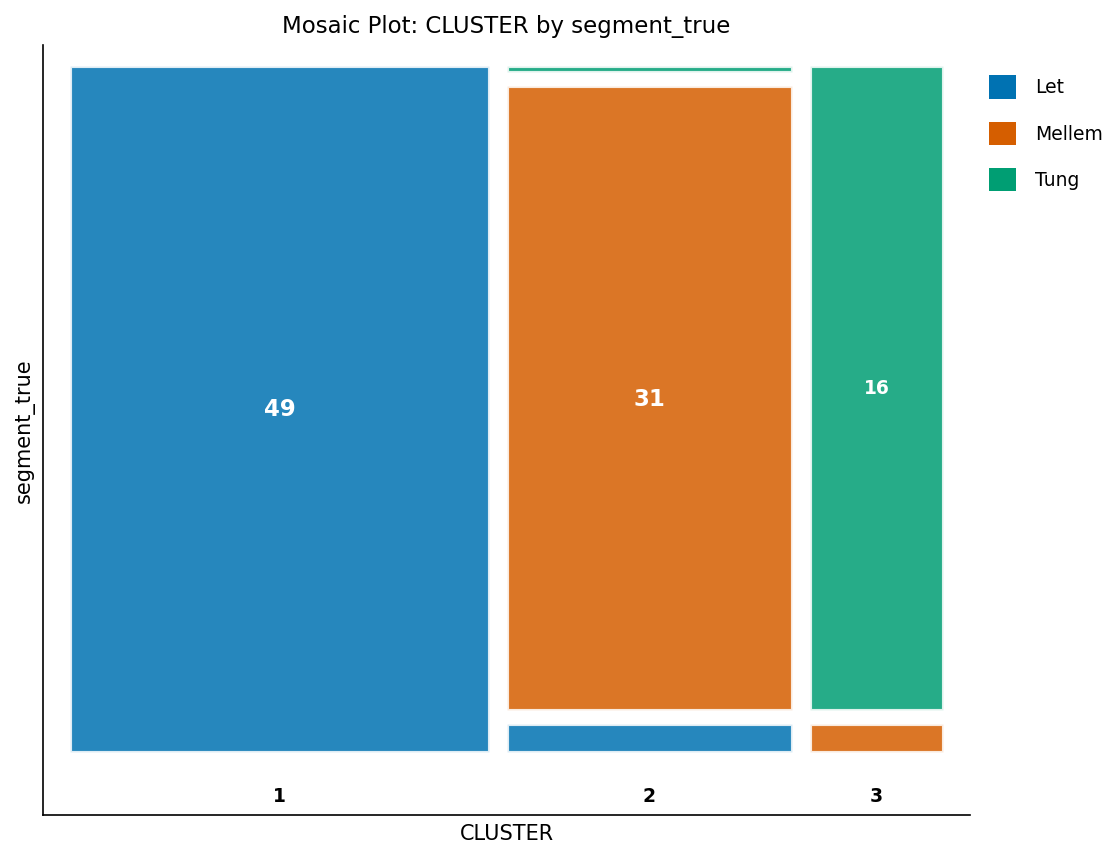

In [6]:
PROCEDURE FREKVENSER data=scored;
   TITEL "Fundet segment vs. udeladt sandt niveau";
   TABLES CLUSTER * segment_true / norow nocol nopercent;
   MÆRKAT CLUSTER="Klynge" segment_true="Sandt segment";
KØR;
TITEL;


## Fortolkning af resultaterne

**Hvad FASTCLUS fandt.** Startende fra en enkelt højreskæv forbrugskolonne uden
etiketter forklarede tre-klynge-k-means-løsningen **89,9%** af variansen i
log-forbrug (samlet R² = 0,899, Pseudo F = 431) og opdelte abonnenter i et
**let** segment (gennemsnit 3,1 GB, n = 49), et **mellem** segment (gennemsnit
12,8 GB, n = 34) og et **tungt** segment (gennemsnit 45,4 GB, n = 17).
Krydstabuleringen mod det udeladte `segment_true` genfandt den plantede
struktur næsten præcist - **96 af 100** abonnenter landede i den klynge, der
matchede deres genererende niveau (Let 49/49, Mellem 31/34, Tung 16/17).

**Hvorfor logskalaen.** Dataforbrug er strengt positivt og tunghalet; at klynge
`log_gb` holder euklidiske afstande meningsfulde og segmentgennemsnittene godt
adskilt, mens den eksponentielle tilbagetransformation genskaber den
realistiske skævhed på GB-skalaen.

**Hvorfor dette betyder noget operationelt.** Hver abonnent forlader modellen
med en hård segmentetiket *og* en afstand-til-centroide-score, så selskabet
kan handle med kalibreret sikkerhed - målrette centrale tunge brugere til
premium-planer med sikkerhed og flagge grænsetilfælde-kunder (stor afstand) til
et nærmere kig. Gennemsnitligt kundeforhold adskiller sig også på tværs af de
fundne segmenter - et krogpunkt for livscyklus- og opsalgstiming.

**Valg af antal segmenter.** At sammenligne `MAXCLUSTERS=` 2, 3 og 4 på samlet
R² og Pseudo F er en gennemsigtig, reproducerbar måde at vælge *k* på: den
store gevinst ved tre klynger og den blot kosmetiske gevinst ved fire (som
opdeler det lette niveau) gjorde tre til det forsvarlige valg her.

**Forhold til finite mixture-modeller.** En finite mixture-model (PROC HPFMM /
PROC FMM) ville tilføje bløde posteriore tilhørsforhold og et
likelihood-baseret BIC for antallet af komponenter. Disse procedurer er endnu
ikke numerisk implementeret i denne build; PROC FASTCLUS leverer den samme
handlingsorienterede segmentering - opdagelse, karakterisering, hård
tildeling og en tillidsindikator - med fuldt numerisk, reproducerbart output i
dag.